# NGX PERFORMANCE(Banking Sector)
### The analysis of the price and volume of each banking equity in the banking sector of the NGX. And the general comparison of the best performing and the least perforing bank in the banking sector from january to september 2026.

### First we understood the data and what we want to analyze. How to know a stock performed well? With the data we have we can find:
- Price return: How much the stock price increased/decreased, yearly and daily
- Volatility: How much the price fluctuates
- Maximum Drawdown: How far the stock fell from a previous high
- Consistency: How often it produces a positive return
- Trading Volume: How actively the stock is being traded.

### So we started by loading the data and cleaning it

# GT CO

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('Guaranty Trust Holding Stock Price History.csv')
gt = data.copy()

In [3]:
gt

,Date,Price,Open,High,Low,Vol.,Change %
0,09/28/2026,137.00,137.00,137.30,136.30,23.82M,0.00%
1,09/25/2026,137.00,137.00,137.20,137.00,12.22M,0.00%
2,09/24/2026,137.00,137.50,137.50,137.00,15.49M,-0.36%
3,09/23/2026,137.50,137.30,138.00,137.00,86.19M,0.15%
4,09/22/2026,137.30,133.90,140.00,134.00,45.92M,2.54%
...,...,...,...,...,...,...,...
180,01/08/2026,99.00,99.00,99.00,98.00,10.23M,0.00%
181,01/07/2026,99.00,99.95,99.00,97.90,11.26M,-0.95%
182,01/06/2026,99.95,97.00,100.05,99.05,20.37M,3.04%
183,01/05/2026,97.00,92.30,98.80,93.00,8.50M,5.09%


In [4]:
gt.dtypes

Date            str
Price       float64
Open        float64
High        float64
Low         float64
Vol.            str
Change %        str
dtype: object

In [5]:
gt['Date'] = pd.to_datetime(gt['Date'], format = '%m/%d/%Y')

In [6]:
## Earliest date
gt['Date'].min()

Timestamp('2026-01-02 00:00:00')

In [7]:
## Latest date
gt['Date'].max()

Timestamp('2026-09-28 00:00:00')

In [8]:
gt['Date'].dtype

dtype('<M8[us]')

In [9]:
gt['Date']

0     2026-09-28
1     2026-09-25
2     2026-09-24
3     2026-09-23
4     2026-09-22
         ...    
180   2026-01-08
181   2026-01-07
182   2026-01-06
183   2026-01-05
184   2026-01-02
Name: Date, Length: 185, dtype: datetime64[us]

In [10]:
### Sort the date by date: That is from January till date
gt = gt.sort_values('Date').reset_index(drop = True)

In [11]:
gt.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2026-01-02,92.30,90.70,92.30,90.70,8.13M,1.76%
1,2026-01-05,97.00,92.30,98.80,93.00,8.50M,5.09%
2,2026-01-06,99.95,97.00,100.05,99.05,20.37M,3.04%
3,2026-01-07,99.00,99.95,99.00,97.90,11.26M,-0.95%
4,2026-01-08,99.00,99.00,99.00,98.00,10.23M,0.00%


In [12]:
gt.info()

<class 'pandas.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      185 non-null    datetime64[us]
 1   Price     185 non-null    float64       
 2   Open      185 non-null    float64       
 3   High      185 non-null    float64       
 4   Low       185 non-null    float64       
 5   Vol.      185 non-null    str           
 6   Change %  185 non-null    str           
dtypes: datetime64[us](1), float64(4), str(2)
memory usage: 12.3 KB


In [13]:
gt.isna().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

In [14]:
gt.duplicated().sum()

np.int64(0)

In [15]:
gt.describe()

,Date,Price,Open,High,Low
count,185,185.00000,185.000000,185.000000,185.000000
mean,2026-05-17 01:33:24.324324,124.10000,123.874595,125.097027,123.068378
min,2026-01-02 00:00:00,92.30000,90.700000,92.300000,90.700000
25%,2026-03-09 00:00:00,117.45000,117.450000,118.450000,117.000000
50%,2026-05-19 00:00:00,128.00000,128.000000,128.900000,127.500000
75%,2026-07-23 00:00:00,132.70000,132.000000,133.800000,131.000000
max,2026-09-28 00:00:00,153.00000,153.000000,156.950000,151.000000
std,NaN,13.63124,13.803358,13.771979,13.667494


# **Price Return**
### Finding the return of prices daily and annualy
## Analyzing the price

In [16]:
gt['Price'].min()

np.float64(92.3)

In [17]:
gt['Price'].max()

np.float64(153.0)

In [18]:
## Finding the dates of the min price
gt.loc[gt['Price'].idxmin(), ['Date', 'Price']]

Date     2026-01-02 00:00:00
Price                   92.3
Name: 0, dtype: object

In [19]:
gt.loc[gt['Price'].idxmax(), ['Date', 'Price']]

Date     2026-05-11 00:00:00
Price                  153.0
Name: 86, dtype: object

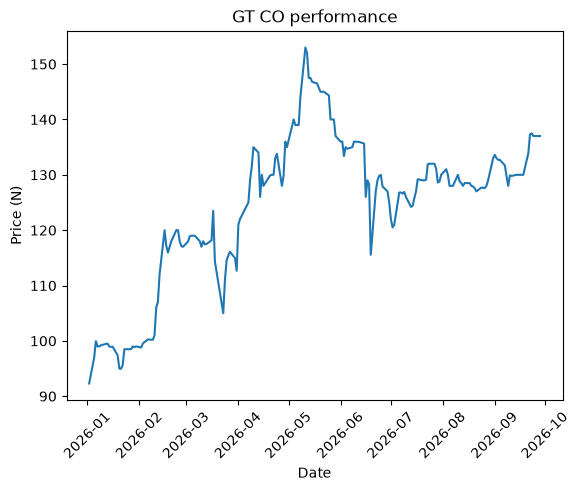

In [20]:
plt.plot(gt['Date'], gt['Price'])

plt.xlabel('Date')
plt.ylabel('Price (N)')
plt.title('GT CO performance')
plt.xticks(rotation = 45)
plt.show()

### This chart shows the movement of GT CO prices from January to September 2026. The stock generally moved upward during the period 

### Now to calculate the total return: That is the difference between the first initial price on the first day and the first initial price on the last day. 

In [21]:
starting_price = gt['Price'].iloc[0]
ending_price = gt['Price'].iloc[-1]

In [22]:
total_return = ((ending_price - starting_price) / starting_price) * 100
total_return
print(f'GT CO total price return is: {round(total_return, 1)}')

GT CO total price return is: 48.4


### This is the total return of the GT CO stock. For example if someone had 100 naira worth of GT CO stocks and all other factors are ignored the price would have increased by 48.4%. That will be 148.40 Naira. But this only shows from the begginning of the year to the end. We need to calculate the daily return.

### The daily return shows how much the price increased each business day

In [23]:
gt['Daily_Return'] = gt['Price'].pct_change()
### This code find the difference with the previous values and divides with the previous price 
## i.e (current price - previous price) / previous price

In [24]:
gt

,Date,Price,Open,High,Low,Vol.,Change %,Daily_Return
0,2026-01-02,92.30,90.70,92.30,90.70,8.13M,1.76%,NaN
1,2026-01-05,97.00,92.30,98.80,93.00,8.50M,5.09%,0.050921
2,2026-01-06,99.95,97.00,100.05,99.05,20.37M,3.04%,0.030412
3,2026-01-07,99.00,99.95,99.00,97.90,11.26M,-0.95%,-0.009505
4,2026-01-08,99.00,99.00,99.00,98.00,10.23M,0.00%,0.000000
...,...,...,...,...,...,...,...,...
180,2026-09-22,137.30,133.90,140.00,134.00,45.92M,2.54%,0.025392
181,2026-09-23,137.50,137.30,138.00,137.00,86.19M,0.15%,0.001457
182,2026-09-24,137.00,137.50,137.50,137.00,15.49M,-0.36%,-0.003636
183,2026-09-25,137.00,137.00,137.20,137.00,12.22M,0.00%,0.000000


### The best and worst trading day

In [25]:
gt.loc[gt['Daily_Return'].idxmax()]

Date            2026-06-22 00:00:00
Price                         127.1
Open                         115.55
High                          127.1
Low                          127.05
Vol.                         15.89M
Change %                     10.00%
Daily_Return               0.099957
Name: 115, dtype: object

In [26]:
## The worst trading day
gt.loc[gt['Daily_Return'].idxmin()]

Date            2026-06-19 00:00:00
Price                        115.55
Open                         128.35
High                         128.95
Low                          115.55
Vol.                         14.01M
Change %                     -9.97%
Daily_Return              -0.099727
Name: 114, dtype: object

# **Volatility**
### How often the price fluctuates

In [27]:
gtdailyreturnmean = gt['Daily_Return'].mean()
gtdailyreturnmean

np.float64(0.002416582882191501)

In [28]:
## Daily Volatility
gtvolatility = gt['Daily_Return'].std()
print(f'Daily volatility:{gtvolatility:.3f}')
print(f'That is a daily volatility of {gtvolatility:.2%}')

Daily volatility:0.023
That is a daily volatility of 2.32%


In [29]:
gt['Date'].count()

np.int64(185)

### This shows the dates where the stock increase and decreased the most

In [30]:
## Annual Volatility
gtannual_volatility = gt['Daily_Return'].std() * np.sqrt(185)
## There are approximately 252 trading days but we are checking for the performance from jan - sept so we count the dates 
print(f'Annualized Volatility:{gtannual_volatility:.2%}')

Annualized Volatility:31.55%


### Analyzing the volume

In [31]:
gt['Vol.'].unique()

<ArrowStringArray>
[ '8.13M',  '8.50M', '20.37M', '11.26M', '10.23M', '10.80M',  '5.18M',
 '19.48M',  '8.11M', '20.66M',
 ...
 '15.88M', '37.48M', '40.55M', '34.23M', '18.48M', '25.86M', '45.92M',
 '86.19M', '15.49M', '23.82M']
Length: 174, dtype: str

In [32]:
gt['Vol.'].dtype

<StringDtype(na_value=nan)>

In [33]:
gt.dtypes

Date            datetime64[us]
Price                  float64
Open                   float64
High                   float64
Low                    float64
Vol.                       str
Change %                   str
Daily_Return           float64
dtype: object

### Cleaning the volume
### Since the volume is in strings and the letters are where values are meant to be we will create a function that replaces the letters at the end of the strings to integers

In [34]:
def convert_volume(x): ## Line 1
    if pd.isna(x): ## Line 2
        return np.nan

    x = str(x).strip().upper() ## Line 3

    if x.endswith('K'): ##Line 4
        return float(x[:-1]) * 1_000
        
    elif x.endswith('M'):  ## Line 5
        return float(x[:-1]) * 1_000_000 

    else:
        return float(x) ## Line 6

### Explaining the function
- (Line 1) Since we are going to be using the 'apply' function we named it convert_volume(x) where the 'x' represents every element that the column is applied to
- (Line 2) The first if statement checks for missing values for every row in the column and returns 'Nan' 
- (Line 3) The next line where the 'x' variable is declared does three things
    1. It converts every element to string
    2. Then strips it of every white space, at the beginning and at the end
    3. Then converts every letter to uppercase

- (Line 4) Here if every element in the column 'endswith K', take everything but the last element and multiply by 1000
- (Line 5) Else if it 'endswith M' take everything but the last element  and mukltiply by 1000000
- (Line 6) Else return the element as it is in the float datatype

In [35]:
gt['Vol.'] = gt['Vol.'].apply(convert_volume)

In [36]:
gt['Vol.']

0       8130000.0
1       8500000.0
2      20370000.0
3      11260000.0
4      10230000.0
          ...    
180    45920000.0
181    86190000.0
182    15490000.0
183    12220000.0
184    23820000.0
Name: Vol., Length: 185, dtype: float64

In [37]:
gt.dtypes

Date            datetime64[us]
Price                  float64
Open                   float64
High                   float64
Low                    float64
Vol.                   float64
Change %                   str
Daily_Return           float64
dtype: object

In [38]:
gt

,Date,Price,Open,High,Low,Vol.,Change %,Daily_Return
0,2026-01-02,92.30,90.70,92.30,90.70,8130000.0,1.76%,NaN
1,2026-01-05,97.00,92.30,98.80,93.00,8500000.0,5.09%,0.050921
2,2026-01-06,99.95,97.00,100.05,99.05,20370000.0,3.04%,0.030412
3,2026-01-07,99.00,99.95,99.00,97.90,11260000.0,-0.95%,-0.009505
4,2026-01-08,99.00,99.00,99.00,98.00,10230000.0,0.00%,0.000000
...,...,...,...,...,...,...,...,...
180,2026-09-22,137.30,133.90,140.00,134.00,45920000.0,2.54%,0.025392
181,2026-09-23,137.50,137.30,138.00,137.00,86190000.0,0.15%,0.001457
182,2026-09-24,137.00,137.50,137.50,137.00,15490000.0,-0.36%,-0.003636
183,2026-09-25,137.00,137.00,137.20,137.00,12220000.0,0.00%,0.000000


In [39]:
monthlyperiod = gt['Date'].dt.to_period('M')

In [40]:
monthlyvol = gt.groupby(monthlyperiod).agg({
    'Vol.' : ['min', 'max', 'mean']
})
monthlyvol

Vol.                           
                min          max          mean
Date                                          
2026-01   5180000.0   39050000.0  1.658905e+07
2026-02   6480000.0   65900000.0  2.776350e+07
2026-03   8740000.0  184380000.0  3.568850e+07
2026-04  16490000.0   73660000.0  3.546650e+07
2026-05   6020000.0   94100000.0  2.640421e+07
2026-06   6960000.0   53910000.0  1.797045e+07
2026-07   7040000.0   74540000.0  1.950739e+07
2026-08   4820000.0   37470000.0  1.308450e+07
2026-09  12220000.0   86190000.0  2.832800e+07

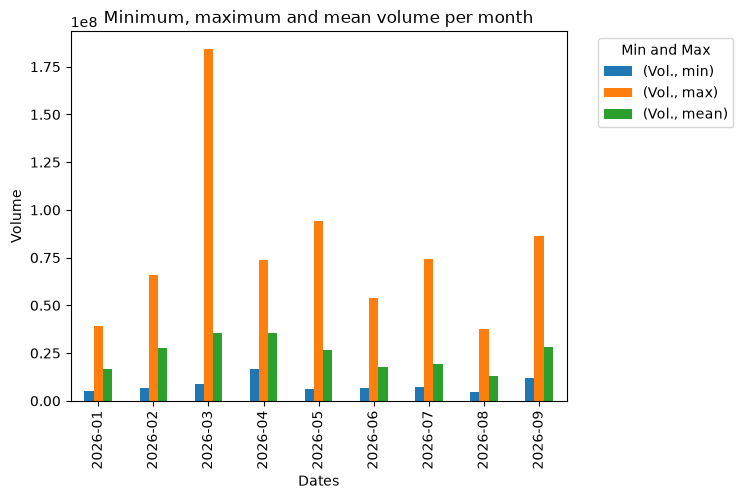

In [41]:
monthlyvol.plot(kind = 'bar')

plt.xlabel('Dates')
plt.ylabel('Volume')
plt.title('Minimum, maximum and mean volume per month')
plt.legend(title = 'Min and Max', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

## Insight
### This chart shows you the volume traded per month. From here we can see that the highest volume sold in GT CO was in March.

## Price performance

In [42]:
gt

,Date,Price,Open,High,Low,Vol.,Change %,Daily_Return
0,2026-01-02,92.30,90.70,92.30,90.70,8130000.0,1.76%,NaN
1,2026-01-05,97.00,92.30,98.80,93.00,8500000.0,5.09%,0.050921
2,2026-01-06,99.95,97.00,100.05,99.05,20370000.0,3.04%,0.030412
3,2026-01-07,99.00,99.95,99.00,97.90,11260000.0,-0.95%,-0.009505
4,2026-01-08,99.00,99.00,99.00,98.00,10230000.0,0.00%,0.000000
...,...,...,...,...,...,...,...,...
180,2026-09-22,137.30,133.90,140.00,134.00,45920000.0,2.54%,0.025392
181,2026-09-23,137.50,137.30,138.00,137.00,86190000.0,0.15%,0.001457
182,2026-09-24,137.00,137.50,137.50,137.00,15490000.0,-0.36%,-0.003636
183,2026-09-25,137.00,137.00,137.20,137.00,12220000.0,0.00%,0.000000


In [43]:
## We are creating a dataframe that organizes first and last price per month 
monthly_price = gt.groupby(monthlyperiod).agg({
    'Price' : ['first', 'last']
})
monthly_price

Price        
          first    last
Date                   
2026-01   92.30   99.00
2026-02   98.80  117.00
2026-03  117.95  112.65
2026-04  120.95  135.00
2026-05  140.00  137.00
2026-06  136.00  125.00
2026-07  122.00  130.00
2026-08  131.00  133.00
2026-09  133.60  137.00

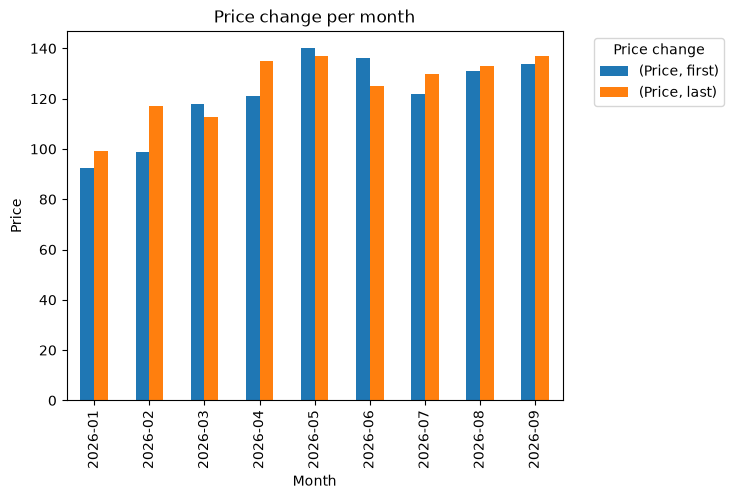

In [44]:
monthly_price.plot(kind = 'bar')

plt.xlabel('Month')
plt.ylabel('Price')
plt.title('Price change per month')
plt.legend(title = 'Price change', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

In [45]:
## Adding a column to the dataframe that shows the return percentage of the per month
monthly_price['Return'] = (
    (monthly_price['Price', 'last'] - monthly_price['Price', 'first'])
    / monthly_price['Price', 'first']
) * 100

monthly_price

Price             Return
          first    last           
Date                              
2026-01   92.30   99.00   7.258938
2026-02   98.80  117.00  18.421053
2026-03  117.95  112.65  -4.493429
2026-04  120.95  135.00  11.616370
2026-05  140.00  137.00  -2.142857
2026-06  136.00  125.00  -8.088235
2026-07  122.00  130.00   6.557377
2026-08  131.00  133.00   1.526718
2026-09  133.60  137.00   2.544910

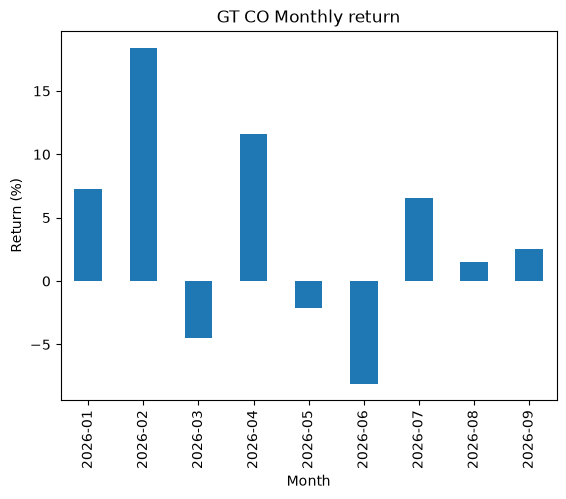

In [46]:
monthly_price['Return'].plot(kind = 'bar')

plt.xlabel('Month')
plt.ylabel('Return (%)')
plt.title('GT CO Monthly return')

plt.show()

## Insight
### This chart shows the monthly return per month during the year. It shows the monthly increase and decrease in price 

# **Maximum Drawdown**
## How far the stock fell from a previous high

In [47]:
gt['Running_Max'] = gt['Price'].cummax()

## The cummax() goes through your Price column from top to bottom and keeps track of the highest price seen so far.

In [48]:
## Calculating Drawdown
gt['Drawdown'] = (
    (gt['Price'] - gt['Running_Max']) / gt['Running_Max']
) * 100

In [49]:
gt['Drawdown'].min()

np.float64(-24.477124183006538)

In [50]:
gt.loc[gt['Drawdown'].idxmin()]

Date            2026-06-19 00:00:00
Price                        115.55
Open                         128.35
High                         128.95
Low                          115.55
Vol.                     14010000.0
Change %                     -9.97%
Daily_Return              -0.099727
Running_Max                   153.0
Drawdown                 -24.477124
Name: 114, dtype: object

### This shows the maximum drop of the stock price from its peak price

In [51]:
gt

,Date,Price,Open,High,Low,Vol.,Change %,Daily_Return,Running_Max,Drawdown
0,2026-01-02,92.30,90.70,92.30,90.70,8130000.0,1.76%,NaN,92.30,0.000000
1,2026-01-05,97.00,92.30,98.80,93.00,8500000.0,5.09%,0.050921,97.00,0.000000
2,2026-01-06,99.95,97.00,100.05,99.05,20370000.0,3.04%,0.030412,99.95,0.000000
3,2026-01-07,99.00,99.95,99.00,97.90,11260000.0,-0.95%,-0.009505,99.95,-0.950475
4,2026-01-08,99.00,99.00,99.00,98.00,10230000.0,0.00%,0.000000,99.95,-0.950475
...,...,...,...,...,...,...,...,...,...,...
180,2026-09-22,137.30,133.90,140.00,134.00,45920000.0,2.54%,0.025392,153.00,-10.261438
181,2026-09-23,137.50,137.30,138.00,137.00,86190000.0,0.15%,0.001457,153.00,-10.130719
182,2026-09-24,137.00,137.50,137.50,137.00,15490000.0,-0.36%,-0.003636,153.00,-10.457516
183,2026-09-25,137.00,137.00,137.20,137.00,12220000.0,0.00%,0.000000,153.00,-10.457516


## ETI NGX performance

In [52]:
data = pd.read_csv('ETI Stock Price History.csv')
eti = data.copy()

In [53]:
eti

,Date,Price,Open,High,Low,Vol.,Change %
0,09/28/2026,70.0,70.0,70.00,70.00,1.70M,1.45%
1,09/25/2026,69.0,66.0,70.00,66.25,7.97M,4.55%
2,09/24/2026,66.0,66.5,66.00,66.00,16.92M,-0.75%
3,09/23/2026,66.5,66.5,66.50,66.50,12.99M,0.00%
4,09/22/2026,66.5,66.5,66.50,66.50,9.31M,-0.23%
...,...,...,...,...,...,...,...
178,01/08/2026,43.5,42.0,43.75,43.50,1.39M,3.57%
179,01/07/2026,42.0,45.9,45.00,42.00,18.64M,-8.50%
180,01/06/2026,45.9,45.9,45.90,45.90,628.90K,0.00%
181,01/05/2026,45.9,41.9,45.90,45.90,425.66K,9.55%


In [54]:
eti['Date'] = pd.to_datetime(eti['Date'], format = '%m/%d/%Y')

In [55]:
eti = eti.sort_values('Date').reset_index(drop = True)

In [56]:
eti.info()

<class 'pandas.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      183 non-null    datetime64[us]
 1   Price     183 non-null    float64       
 2   Open      183 non-null    float64       
 3   High      183 non-null    float64       
 4   Low       183 non-null    float64       
 5   Vol.      183 non-null    str           
 6   Change %  183 non-null    str           
dtypes: datetime64[us](1), float64(4), str(2)
memory usage: 12.2 KB


In [57]:
eti.dtypes

Date        datetime64[us]
Price              float64
Open               float64
High               float64
Low                float64
Vol.                   str
Change %               str
dtype: object

In [58]:
eti.isnull().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

In [59]:
eti.duplicated().sum()

np.int64(0)

In [60]:
eti['Price'].min()

np.float64(41.9)

In [61]:
eti['Price'].max()

np.float64(97.4)

In [62]:
eti.loc[eti['Price'].idxmin()]

Date        2026-01-02 00:00:00
Price                      41.9
Open                       41.9
High                       41.9
Low                        41.9
Vol.                    123.93K
Change %                  0.00%
Name: 0, dtype: object

In [63]:
eti.loc[eti['Price'].idxmax()]

Date        2026-05-12 00:00:00
Price                      97.4
Open                       93.0
High                       97.4
Low                        97.4
Vol.                    959.18K
Change %                  4.73%
Name: 87, dtype: object

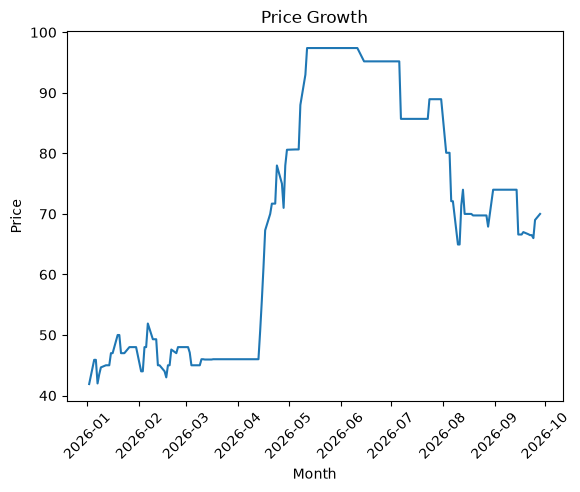

In [64]:
plt.plot(eti['Date'], eti['Price'])

plt.xlabel('Month')
plt.ylabel('Price')
plt.title('Price Growth')
plt.xticks(rotation = 45)
plt.show()

In [65]:
## price_return
starting_price = eti['Price'].iloc[0]
ending_price = eti['Price'].iloc[-1]

price_return = (
    (ending_price - starting_price) / starting_price
) * 100

price_return
print(f'The total return for ETI:{price_return:.2f}%')

The total return for ETI:67.06%


In [66]:
eti['Daily_Return'] = eti['Price'].pct_change()

In [67]:
eti

,Date,Price,Open,High,Low,Vol.,Change %,Daily_Return
0,2026-01-02,41.9,41.9,41.90,41.90,123.93K,0.00%,NaN
1,2026-01-05,45.9,41.9,45.90,45.90,425.66K,9.55%,0.095465
2,2026-01-06,45.9,45.9,45.90,45.90,628.90K,0.00%,0.000000
3,2026-01-07,42.0,45.9,45.00,42.00,18.64M,-8.50%,-0.084967
4,2026-01-08,43.5,42.0,43.75,43.50,1.39M,3.57%,0.035714
...,...,...,...,...,...,...,...,...
178,2026-09-22,66.5,66.5,66.50,66.50,9.31M,-0.23%,-0.002251
179,2026-09-23,66.5,66.5,66.50,66.50,12.99M,0.00%,0.000000
180,2026-09-24,66.0,66.5,66.00,66.00,16.92M,-0.75%,-0.007519
181,2026-09-25,69.0,66.0,70.00,66.25,7.97M,4.55%,0.045455


In [68]:
## The best trading day
eti.loc[eti['Daily_Return'].idxmax()]

Date            2026-04-14 00:00:00
Price                          50.6
Open                           46.0
High                           50.6
Low                            48.0
Vol.                          4.25M
Change %                     10.00%
Daily_Return                    0.1
Name: 68, dtype: object

In [69]:
## The worst Trading day
eti.loc[eti['Daily_Return'].idxmin()]

Date            2026-09-15 00:00:00
Price                          66.6
Open                           74.0
High                           66.6
Low                            66.6
Vol.                          5.34M
Change %                    -10.00%
Daily_Return                   -0.1
Name: 173, dtype: object

In [70]:
## Volatility
etidaily_volatility = eti['Daily_Return'].std()
print(f'The daily volatility:{etidaily_volatility:.2%}')

The daily volatility:3.52%


In [71]:
eti['Date'].count()

np.int64(183)

In [72]:
etiannual_volatility = eti['Daily_Return'].std() * np.sqrt(183)
print(f'Annualized Volatility:{etiannual_volatility:.2%}')

Annualized Volatility:47.57%


In [73]:
## Checking the volume
eti['Vol.']

0      123.93K
1      425.66K
2      628.90K
3       18.64M
4        1.39M
        ...   
178      9.31M
179     12.99M
180     16.92M
181      7.97M
182      1.70M
Name: Vol., Length: 183, dtype: str

In [74]:
eti['Vol.'] = eti['Vol.'].apply(convert_volume)

In [75]:
eti

,Date,Price,Open,High,Low,Vol.,Change %,Daily_Return
0,2026-01-02,41.9,41.9,41.90,41.90,123930.0,0.00%,NaN
1,2026-01-05,45.9,41.9,45.90,45.90,425660.0,9.55%,0.095465
2,2026-01-06,45.9,45.9,45.90,45.90,628900.0,0.00%,0.000000
3,2026-01-07,42.0,45.9,45.00,42.00,18640000.0,-8.50%,-0.084967
4,2026-01-08,43.5,42.0,43.75,43.50,1390000.0,3.57%,0.035714
...,...,...,...,...,...,...,...,...
178,2026-09-22,66.5,66.5,66.50,66.50,9310000.0,-0.23%,-0.002251
179,2026-09-23,66.5,66.5,66.50,66.50,12990000.0,0.00%,0.000000
180,2026-09-24,66.0,66.5,66.00,66.00,16920000.0,-0.75%,-0.007519
181,2026-09-25,69.0,66.0,70.00,66.25,7970000.0,4.55%,0.045455


In [76]:
monthly_period = eti['Date'].dt.to_period('M')

In [77]:
etivol = eti.groupby(monthly_period).agg({
    'Vol.' : ['min', 'max', 'mean']
})
etivol

Vol.                          
              min         max          mean
Date                                       
2026-01  123930.0  18640000.0  1.712073e+06
2026-02  416290.0  11640000.0  3.639765e+06
2026-03  115470.0   4760000.0  9.254330e+05
2026-04  109380.0  24920000.0  5.446510e+06
2026-05  293750.0   5750000.0  1.389558e+06
2026-06    7390.0   7320000.0  9.644171e+05
2026-07   24580.0   5390000.0  1.179393e+06
2026-08  238580.0   7850000.0  1.682828e+06
2026-09  142000.0  16920000.0  3.812234e+06

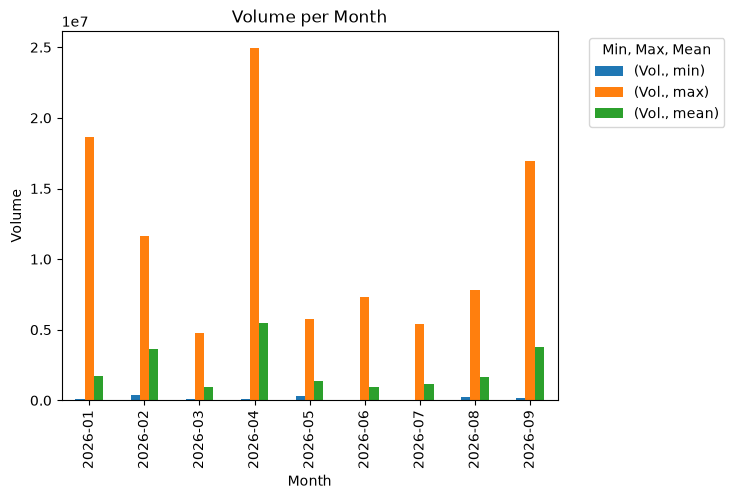

In [78]:
etivol.plot(kind = 'bar')

plt.xlabel('Month')
plt.ylabel('Volume')
plt.title('Volume per Month')
plt.legend(title = 'Min, Max, Mean', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

In [79]:
## Price Performance
etimonthly_price = eti.groupby(monthly_period).agg({
    'Price' : ['first', 'last']
})
etimonthly_price

Price       
         first   last
Date                 
2026-01  41.90  48.00
2026-02  44.00  48.00
2026-03  48.00  46.00
2026-04  46.00  80.60
2026-05  80.65  97.40
2026-06  97.40  95.20
2026-07  95.20  88.95
2026-08  80.10  74.00
2026-09  74.00  70.00

In [80]:
etimonthly_price['Monthly_Return'] = (
    (etimonthly_price['Price', 'last'] - etimonthly_price['Price', 'first']) / 
    etimonthly_price ['Price', 'first']
) * 100

etimonthly_price

Price        Monthly_Return
         first   last               
Date                                
2026-01  41.90  48.00      14.558473
2026-02  44.00  48.00       9.090909
2026-03  48.00  46.00      -4.166667
2026-04  46.00  80.60      75.217391
2026-05  80.65  97.40      20.768754
2026-06  97.40  95.20      -2.258727
2026-07  95.20  88.95      -6.565126
2026-08  80.10  74.00      -7.615481
2026-09  74.00  70.00      -5.405405

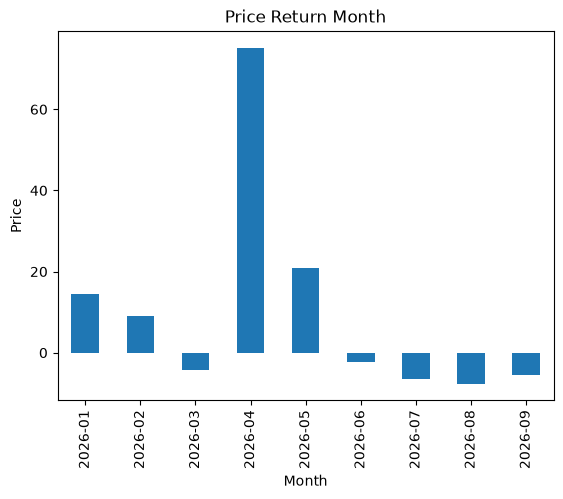

In [81]:
etimonthly_price['Monthly_Return'].plot(kind = 'bar')
plt.xlabel('Month')
plt.ylabel('Price')
plt.title('Price Return Month')
plt.show()

In [82]:
## Maximim Drawdown
eti['Running_Max'] = eti['Price'].cummax()

In [83]:
eti['Drawdown'] = (
    (eti['Price'] - eti['Running_Max']) / eti['Running_Max']
) * 100 

In [84]:
eti.loc[eti['Drawdown'].idxmin()]

Date            2026-08-10 00:00:00
Price                         64.95
Open                           72.1
High                          64.95
Low                           64.95
Vol.                      2030000.0
Change %                     -9.92%
Daily_Return              -0.099168
Running_Max                    97.4
Drawdown                 -33.316222
Name: 148, dtype: object

In [85]:
eti

,Date,Price,Open,High,Low,Vol.,Change %,Daily_Return,Running_Max,Drawdown
0,2026-01-02,41.9,41.9,41.90,41.90,123930.0,0.00%,NaN,41.9,0.000000
1,2026-01-05,45.9,41.9,45.90,45.90,425660.0,9.55%,0.095465,45.9,0.000000
2,2026-01-06,45.9,45.9,45.90,45.90,628900.0,0.00%,0.000000,45.9,0.000000
3,2026-01-07,42.0,45.9,45.00,42.00,18640000.0,-8.50%,-0.084967,45.9,-8.496732
4,2026-01-08,43.5,42.0,43.75,43.50,1390000.0,3.57%,0.035714,45.9,-5.228758
...,...,...,...,...,...,...,...,...,...,...
178,2026-09-22,66.5,66.5,66.50,66.50,9310000.0,-0.23%,-0.002251,97.4,-31.724846
179,2026-09-23,66.5,66.5,66.50,66.50,12990000.0,0.00%,0.000000,97.4,-31.724846
180,2026-09-24,66.0,66.5,66.00,66.00,16920000.0,-0.75%,-0.007519,97.4,-32.238193
181,2026-09-25,69.0,66.0,70.00,66.25,7970000.0,4.55%,0.045455,97.4,-29.158111


In [86]:
data = pd.read_csv('Wema Bank Stock Price History.csv')
wema = data.copy()
wema

,Date,Price,Open,High,Low,Vol.,Change %
0,09/28/2026,30.10,30.75,30.10,30.10,16.02M,-2.11%
1,09/25/2026,30.75,30.55,30.75,30.75,1.33M,0.65%
2,09/24/2026,30.55,31.80,31.00,30.55,3.79M,-3.93%
3,09/23/2026,31.80,32.00,32.00,31.75,5.90M,-0.63%
4,09/22/2026,32.00,31.95,32.00,31.70,4.50M,0.16%
...,...,...,...,...,...,...,...
158,02/06/2026,25.00,25.00,25.00,24.65,31.37M,0.00%
159,02/05/2026,25.00,25.30,25.90,25.00,5.11M,-1.19%
160,02/04/2026,25.30,24.95,25.90,24.95,26.66M,1.40%
161,02/03/2026,24.95,23.95,24.95,23.95,11.52M,4.18%


In [87]:
wema['Date'] = pd.to_datetime(wema['Date'], format = '%m/%d/%Y')

In [88]:
wema = wema.sort_values('Date').reset_index(drop = True)

In [89]:
wema

,Date,Price,Open,High,Low,Vol.,Change %
0,2026-02-02,23.95,23.40,24.00,23.50,8.00M,2.35%
1,2026-02-03,24.95,23.95,24.95,23.95,11.52M,4.18%
2,2026-02-04,25.30,24.95,25.90,24.95,26.66M,1.40%
3,2026-02-05,25.00,25.30,25.90,25.00,5.11M,-1.19%
4,2026-02-06,25.00,25.00,25.00,24.65,31.37M,0.00%
...,...,...,...,...,...,...,...
158,2026-09-22,32.00,31.95,32.00,31.70,4.50M,0.16%
159,2026-09-23,31.80,32.00,32.00,31.75,5.90M,-0.63%
160,2026-09-24,30.55,31.80,31.00,30.55,3.79M,-3.93%
161,2026-09-25,30.75,30.55,30.75,30.75,1.33M,0.65%


In [90]:
wema.isnull().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

In [91]:
wema.duplicated().sum()

np.int64(0)

In [92]:
wema.dtypes

Date        datetime64[us]
Price              float64
Open               float64
High               float64
Low                float64
Vol.                   str
Change %               str
dtype: object

In [93]:
wema.loc[wema['Price'].idxmax()]

Date        2026-04-29 00:00:00
Price                      36.0
Open                       35.0
High                       36.0
Low                        34.0
Vol.                     65.70M
Change %                  2.86%
Name: 59, dtype: object

In [94]:
wema.loc[wema['Price'].idxmin()]

Date        2026-02-02 00:00:00
Price                     23.95
Open                       23.4
High                       24.0
Low                        23.5
Vol.                      8.00M
Change %                  2.35%
Name: 0, dtype: object

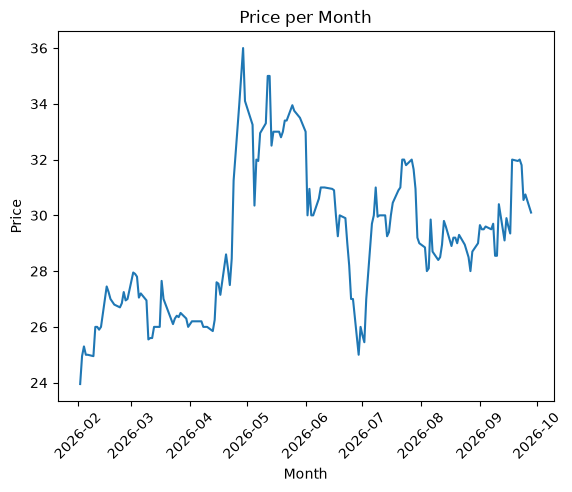

In [95]:
plt.plot(wema['Date'], wema['Price'])

plt.xlabel('Month')
plt.ylabel('Price')
plt.title('Price per Month')
plt.xticks(rotation = 45)
plt.show()

In [96]:
## Total price return
starting_price = wema['Price'].iloc[0]
ending_price = wema['Price'].iloc[-1]

total_return_price = (
    (ending_price - starting_price) / starting_price
)* 100

print(f'The total return price is: {total_return_price:.2f}')

The total return price is: 25.68


In [97]:
## Daily Return
wema['Daily_Return'] = wema['Price'].pct_change()

In [98]:
## Worst Trading Day
wema.loc[wema['Daily_Return'].idxmin()]

Date            2026-06-02 00:00:00
Price                          30.0
Open                           33.0
High                          31.85
Low                            30.0
Vol.                         18.96M
Change %                     -9.09%
Daily_Return              -0.090909
Name: 80, dtype: object

In [99]:
## Best Trading Day
wema.loc[wema['Daily_Return'].idxmax()]

Date            2026-07-06 00:00:00
Price                          29.7
Open                           27.0
High                           29.7
Low                            27.5
Vol.                          6.26M
Change %                     10.00%
Daily_Return                    0.1
Name: 103, dtype: object

In [100]:
## Volatility
wemadaily_vol = wema['Daily_Return'].std()
print(f'Wema annual volatility: {wemadaily_vol:.2%}')

Wema annual volatility: 2.99%


In [101]:
wema['Date'].count()

np.int64(163)

In [102]:
wemaannual_vol = wema['Daily_Return'].std() * np.sqrt(163)
print(f'The wema annual volatility: {wemaannual_vol:.2%}')

The wema annual volatility: 38.23%


In [103]:
wema

,Date,Price,Open,High,Low,Vol.,Change %,Daily_Return
0,2026-02-02,23.95,23.40,24.00,23.50,8.00M,2.35%,NaN
1,2026-02-03,24.95,23.95,24.95,23.95,11.52M,4.18%,0.041754
2,2026-02-04,25.30,24.95,25.90,24.95,26.66M,1.40%,0.014028
3,2026-02-05,25.00,25.30,25.90,25.00,5.11M,-1.19%,-0.011858
4,2026-02-06,25.00,25.00,25.00,24.65,31.37M,0.00%,0.000000
...,...,...,...,...,...,...,...,...
158,2026-09-22,32.00,31.95,32.00,31.70,4.50M,0.16%,0.001565
159,2026-09-23,31.80,32.00,32.00,31.75,5.90M,-0.63%,-0.006250
160,2026-09-24,30.55,31.80,31.00,30.55,3.79M,-3.93%,-0.039308
161,2026-09-25,30.75,30.55,30.75,30.75,1.33M,0.65%,0.006547


In [104]:
wema['Vol.'].unique()

<ArrowStringArray>
[ '8.00M', '11.52M', '26.66M',  '5.11M', '31.37M', '15.58M', '10.09M',
 '14.84M',  '9.12M',  '7.67M',
 ...
 '14.03M',  '1.92M',  '2.60M',  '3.28M', '22.27M',  '8.40M',  '4.50M',
  '3.79M',  '1.33M', '16.02M']
Length: 156, dtype: str

In [105]:
wema['Vol.'] = wema['Vol.'].apply(convert_volume)

In [106]:
wema

,Date,Price,Open,High,Low,Vol.,Change %,Daily_Return
0,2026-02-02,23.95,23.40,24.00,23.50,8000000.0,2.35%,NaN
1,2026-02-03,24.95,23.95,24.95,23.95,11520000.0,4.18%,0.041754
2,2026-02-04,25.30,24.95,25.90,24.95,26660000.0,1.40%,0.014028
3,2026-02-05,25.00,25.30,25.90,25.00,5110000.0,-1.19%,-0.011858
4,2026-02-06,25.00,25.00,25.00,24.65,31370000.0,0.00%,0.000000
...,...,...,...,...,...,...,...,...
158,2026-09-22,32.00,31.95,32.00,31.70,4500000.0,0.16%,0.001565
159,2026-09-23,31.80,32.00,32.00,31.75,5900000.0,-0.63%,-0.006250
160,2026-09-24,30.55,31.80,31.00,30.55,3790000.0,-3.93%,-0.039308
161,2026-09-25,30.75,30.55,30.75,30.75,1330000.0,0.65%,0.006547


In [107]:
wemavol = wema.groupby(monthlyperiod).agg({
    'Vol.' : ['min', 'max', 'mean']
})

wemavol

Vol.                           
               min          max          mean
Date                                         
2026-01  4810000.0   31370000.0  1.437762e+07
2026-02  3380000.0  213390000.0  7.079300e+07
2026-03  1970000.0  282580000.0  4.414750e+07
2026-04  3000000.0   74750000.0  1.141550e+07
2026-05   958350.0   24340000.0  6.157808e+06
2026-06  1870000.0   17290000.0  7.850909e+06
2026-07  1290000.0    7720000.0  3.701739e+06
2026-08   740830.0   23240000.0  7.080046e+06

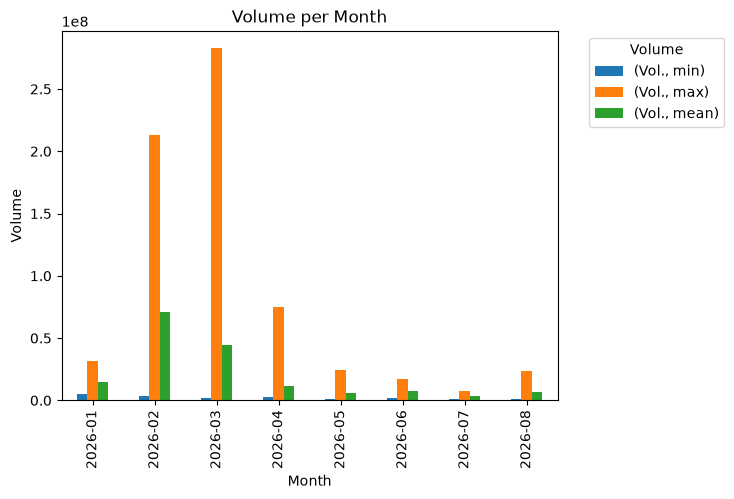

In [108]:
wemavol.plot(kind = 'bar')

plt.xlabel('Month')
plt.ylabel('Volume')
plt.title('Volume per Month')
plt.legend(title = 'Volume', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

In [109]:
wemaprice = wema.groupby(monthlyperiod).agg({
    'Price' : ['first', 'last']
})
wemaprice

Price       
         first   last
Date                 
2026-01  23.95  27.95
2026-02  27.90  26.10
2026-03  26.20  34.10
2026-04  33.25  30.00
2026-05  30.95  26.00
2026-06  25.70  29.20
2026-07  29.00  29.50
2026-08  29.50  30.10

In [110]:
wemaprice['Monthly_Return'] = (
    (wemaprice['Price', 'last'] - wemaprice['Price', 'first']) / wemaprice['Price', 'first']
) * 100
wemaprice

Price        Monthly_Return
         first   last               
Date                                
2026-01  23.95  27.95      16.701461
2026-02  27.90  26.10      -6.451613
2026-03  26.20  34.10      30.152672
2026-04  33.25  30.00      -9.774436
2026-05  30.95  26.00     -15.993538
2026-06  25.70  29.20      13.618677
2026-07  29.00  29.50       1.724138
2026-08  29.50  30.10       2.033898

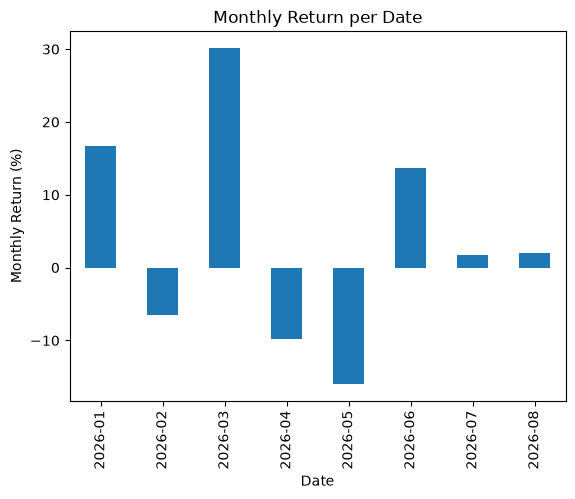

In [111]:
wemaprice['Monthly_Return'].plot(kind = 'bar')

plt.xlabel('Date')
plt.ylabel('Monthly Return (%)')
plt.title('Monthly Return per Date')
plt.show()

In [112]:
## Maximum Drawdown 
wema['Running_Max'] = wema['Price'].cummax()

In [113]:
wema

,Date,Price,Open,High,Low,Vol.,Change %,Daily_Return,Running_Max
0,2026-02-02,23.95,23.40,24.00,23.50,8000000.0,2.35%,NaN,23.95
1,2026-02-03,24.95,23.95,24.95,23.95,11520000.0,4.18%,0.041754,24.95
2,2026-02-04,25.30,24.95,25.90,24.95,26660000.0,1.40%,0.014028,25.30
3,2026-02-05,25.00,25.30,25.90,25.00,5110000.0,-1.19%,-0.011858,25.30
4,2026-02-06,25.00,25.00,25.00,24.65,31370000.0,0.00%,0.000000,25.30
...,...,...,...,...,...,...,...,...,...
158,2026-09-22,32.00,31.95,32.00,31.70,4500000.0,0.16%,0.001565,36.00
159,2026-09-23,31.80,32.00,32.00,31.75,5900000.0,-0.63%,-0.006250,36.00
160,2026-09-24,30.55,31.80,31.00,30.55,3790000.0,-3.93%,-0.039308,36.00
161,2026-09-25,30.75,30.55,30.75,30.75,1330000.0,0.65%,0.006547,36.00


In [119]:
## Drawdown 
wema['Drawdown'] = (
    (wema['Price'] - wema['Running_Max']) / wema['Running_Max']
) * 100



In [120]:
wema['Drawdown'].min()

np.float64(-30.555555555555557)

In [121]:
wema.loc[wema['Drawdown'].idxmin()]

Date            2026-06-29 00:00:00
Price                          25.0
Open                           27.0
High                           26.5
Low                            25.0
Vol.                     11910000.0
Change %                     -7.41%
Daily_Return              -0.074074
Running_Max                    36.0
Drawdown                 -30.555556
Name: 98, dtype: object

# Comparison of the stocks

In [124]:
comparison = pd.DataFrame({
    'Stocks': ['GTCO', 'ETI', 'WEMA'],
    'Total_Return' : [48.40, 67.06, 25.68],
    'Annual_Volatility': [31.55, 47.57, 38.23],
    'Max_Drawdown': [-24.48, -33.31, -30.55]
})
comparison

,Stocks,Total_Return,Annual_Volatility,Max_Drawdown
0,GTCO,48.40,31.55,-24.48
1,ETI,67.06,47.57,-33.31
2,WEMA,25.68,38.23,-30.55


## Visualizing the comparison of the stocks. We are going to find the stock with the highest return, Annual volatility and maximum drawdown.

### First with the total return

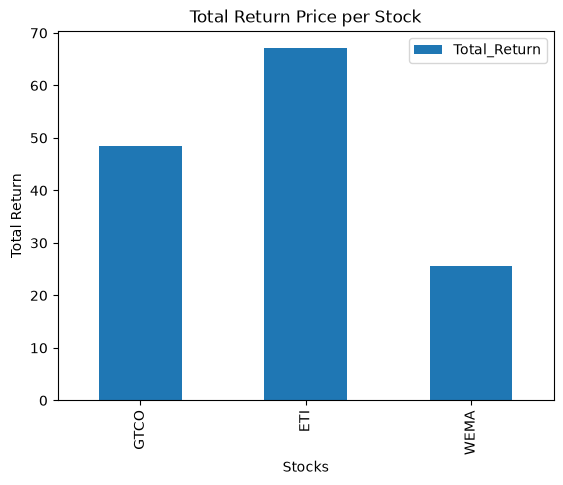

In [135]:
##Viz
comparison.plot(x = 'Stocks', y = 'Total_Return', kind = 'bar')
plt.xlabel('Stocks')
plt.ylabel('Total Return')
plt.title('Total Return Price per Stock')
plt.show()


### This chart represents the total return of each bank stock from January to the end of september with Ecobank(ETI) as the stock with the highest total price return with an increase of 67.06% followed up by GT bank (GTCO) with an increase of 48.40%

### Annual Volatility

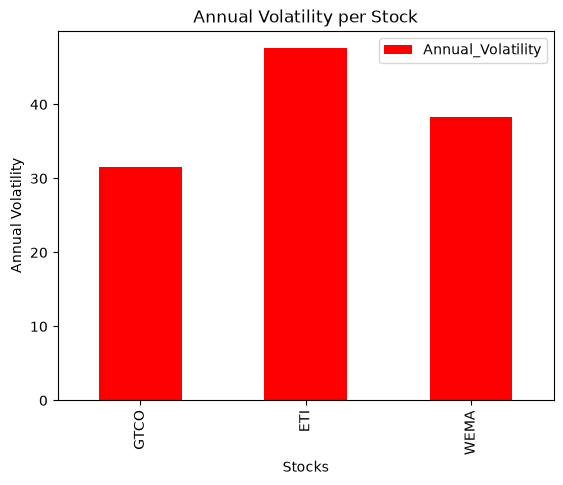

In [134]:
comparison.plot(x = 'Stocks', y = 'Annual_Volatility', kind = 'bar', color = 'r')


plt.xlabel('Stocks')
plt.ylabel('Annual Volatility')
plt.title('Annual Volatility per Stock')
plt.show()

### This chart shows the stocks in the banking sector with the highest annual fluctuation in price (Volatility) which is the ETI with an annual volatility of 47.57% followed up by WEMA with a percentage of 38.23%

### Maximum Drawdown

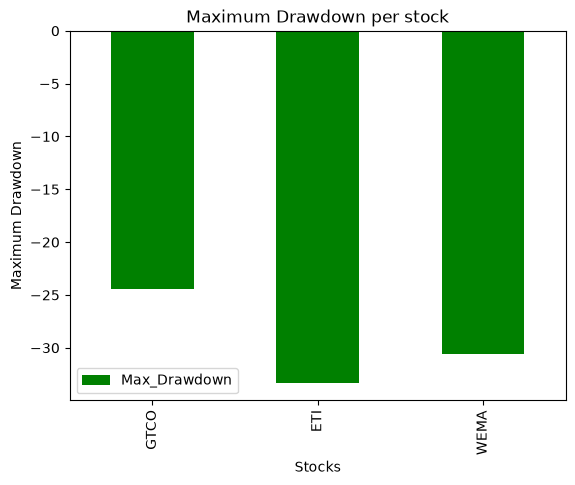

In [136]:
comparison.plot(x = 'Stocks', y = 'Max_Drawdown', kind = 'bar', color = 'g')

plt.xlabel('Stocks')
plt.ylabel('Maximum Drawdown')
plt.title('Maximum Drawdown per stock')
plt.show()

### In this chart we ca see that ETI has the highest maximum drawdown by 33.31%, followed closely by WEMA with a maximum drawdown of -30.55%

### We can also show all that visually like this

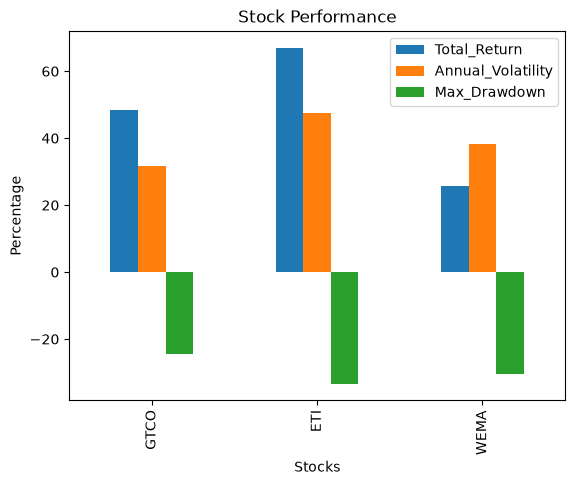

In [138]:
comparison.plot(x = 'Stocks', y = ['Total_Return', 'Annual_Volatility', 'Max_Drawdown'], kind = 'bar')

plt.xlabel('Stocks')
plt.ylabel('Percentage')
plt.title('Stock Performance')
plt.show()

## **But this is not advisable**